# Lab 02 — Shared Simulation & Evaluation Harness

Phase 2 of the project sequence: build the **Simulation & Evaluation Node** that every controller
(PID now; MPC / robust / RL later) must pass through.

Architecture reminder:

```
Controller (topology A/B/C)  -->  evaluate_controller(...)  -->  scorecard JSON
                                         |
                                   pass/fail + scalar score
```

Principle: **code computes metrics**; an LLM (later) only reads the scorecard to choose or re-query agents.


## 1. Evaluate the Lab_01 baseline PID

Same CTMS gains as Lab_01 (`Kp=100`, `Ki=200`, `Kd=10`) across a multi-scenario suite.


In [1]:
from pprint import pprint

from dc_motor import (
    PIDController,
    default_scenarios,
    evaluate_controller,
    scorecard_to_json,
)

pid = PIDController(Kp=100.0, Ki=200.0, Kd=10.0, name="PID_CTMS_baseline")
scenarios = default_scenarios()

print("Scenarios:")
for sc in scenarios:
    print(f"  - {sc.name}: {sc.description}")

scorecard = evaluate_controller(pid, scenarios=scenarios)
print("\nSummary:")
pprint(scorecard["summary"])


Scenarios:
  - step_1rads: Unit step reference omega_ref = 1 rad/s, no disturbance.
  - load_disturbance: Step reference then load torque 0.05 N·m at t = 1.5 s.
  - plant_mismatch: Step reference on mismatched plant (J×1.3, b×0.7, R×1.2).
  - noisy_measurement: Step reference with Gaussian speed sensor noise.

Summary:
{'all_constraints_pass': False,
 'mean_scalar_score': 1.845777755226998,
 'n_scenarios': 4}


## 2. Per-scenario metrics and constraint checks

Default soft constraints (editable for orchestration later):

- `settling_time_s <= 2.0`
- `overshoot_pct <= 15`
- `steady_state_error <= 0.05`

Scalar score (lower is better): weighted sum of `ITAE`, overshoot, control effort, saturation time.


In [2]:
for item in scorecard["scenarios"]:
    print("=" * 60)
    print(item["name"])
    print(item["description"])
    print("constraints all_pass:", item["constraints"]["all_pass"])
    print("scalar_score:", f"{item['scalar_score']:.6g}")
    print("metrics:")
    for k, v in item["metrics"].items():
        if v is None or (isinstance(v, float) and (v != v)):  # NaN check
            print(f"  {k}: n/a")
        else:
            print(f"  {k}: {v:.6g}")


step_1rads
Unit step reference omega_ref = 1 rad/s, no disturbance.
constraints all_pass: True
scalar_score: 0.525079
metrics:
  rise_time_s: 0.713
  settling_time_s: 1.242
  overshoot_pct: 0
  steady_state_error: 7.61816e-05
  IAE: 0.437736
  ISE: 0.275246
  ITAE: 0.14256
  control_effort: 31.6419
  saturation_time_s: 0.661
load_disturbance
Step reference then load torque 0.05 N·m at t = 1.5 s.
constraints all_pass: False
scalar_score: 3.15227
metrics:
  rise_time_s: 0.713
  settling_time_s: n/a
  overshoot_pct: 0
  steady_state_error: 0.302409
  IAE: 1.2595
  ISE: 0.552958
  ITAE: 2.37001
  control_effort: 46.6162
  saturation_time_s: 3.161
plant_mismatch
Step reference on mismatched plant (J×1.3, b×0.7, R×1.2).
constraints all_pass: True
scalar_score: 0.418385
metrics:
  rise_time_s: 0.533
  settling_time_s: 0.893
  overshoot_pct: 0
  steady_state_error: 2.75442e-05
  IAE: 0.380516
  ISE: 0.260147
  ITAE: 0.0970468
  control_effort: 27.0838
  saturation_time_s: 0.505
noisy_measureme

## 3. LLM / orchestrator-ready JSON scorecard

Trajectories are kept in memory for plotting but **stripped** from the JSON export so agents
consume compact, deterministic numbers only.


In [3]:
print(scorecard_to_json(scorecard))


{
  "controller": "PID_CTMS_baseline",
  "constraints": {
    "settling_time_s": {
      "op": "<=",
      "limit": 2.0
    },
    "overshoot_pct": {
      "op": "<=",
      "limit": 15.0
    },
    "steady_state_error": {
      "op": "<=",
      "limit": 0.05
    }
  },
  "score_weights": {
    "ITAE": 1.0,
    "overshoot_pct": 0.05,
    "control_effort": 0.01,
    "saturation_time_s": 0.1
  },
  "scenarios": [
    {
      "name": "step_1rads",
      "description": "Unit step reference omega_ref = 1 rad/s, no disturbance.",
      "metrics": {
        "rise_time_s": 0.7130000000000001,
        "settling_time_s": 1.242,
        "overshoot_pct": 0.0,
        "steady_state_error": 7.618163319556004e-05,
        "IAE": 0.437735687059118,
        "ISE": 0.27524552559881793,
        "ITAE": 0.14256017114058187,
        "control_effort": 31.64192479944535,
        "saturation_time_s": 0.661
      },
      "constraints": {
        "all_pass": 1,
        "checks": {
          "settling_time_s":

## 4. Plot one scenario (optional visualization)

Humans inspect plots; the orchestrator should still decide from the scorecard.


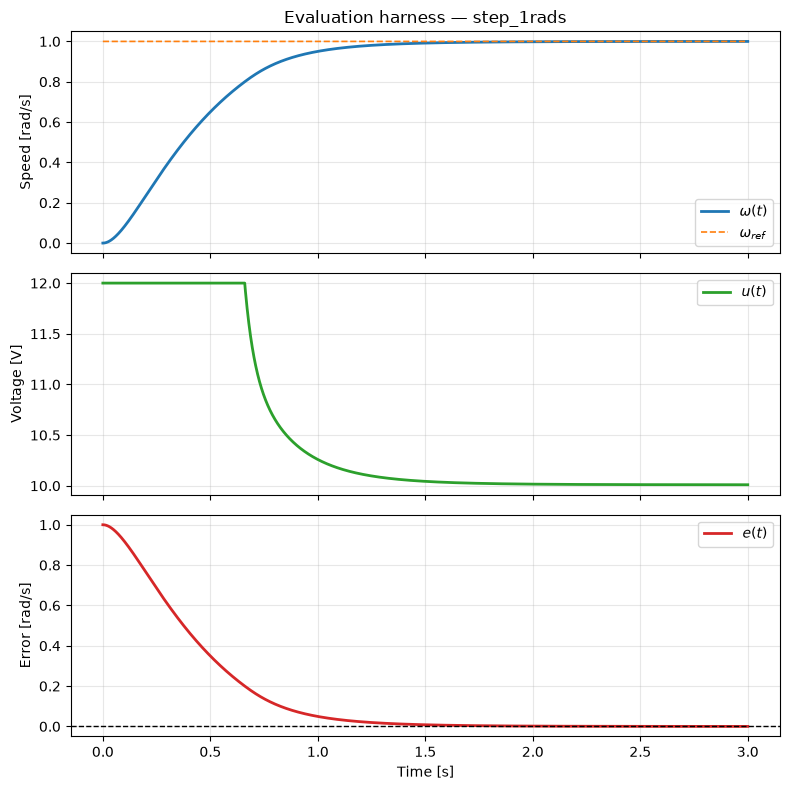

In [4]:
import matplotlib.pyplot as plt

# Plot the nominal step scenario
step = next(s for s in scorecard["scenarios"] if s["name"] == "step_1rads")
tr = step["trajectories"]

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(tr["t"], tr["omega"], lw=2, label=r"$\omega(t)$")
axes[0].plot(tr["t"], tr["reference"], ls="--", lw=1.2, label=r"$\omega_{ref}$")
axes[0].set_ylabel("Speed [rad/s]")
axes[0].set_title("Evaluation harness — step_1rads")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(tr["t"], tr["u"], color="C2", lw=2, label=r"$u(t)$")
axes[1].set_ylabel("Voltage [V]")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(tr["t"], tr["e"], color="C3", lw=2, label=r"$e(t)$")
axes[2].axhline(0.0, color="k", ls="--", lw=1)
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Error [rad/s]")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.tight_layout()
plt.show()


## 5. Compare two PID candidates (preview of orchestration)

Same evaluator, two controllers — the pattern future MPC/robust/RL agents will use.


In [5]:
pid_soft = PIDController(Kp=40.0, Ki=80.0, Kd=5.0, name="PID_softer")

card_a = evaluate_controller(pid, scenarios=scenarios)
card_b = evaluate_controller(pid_soft, scenarios=scenarios)

print(f"{card_a['controller']}: mean_score={card_a['summary']['mean_scalar_score']:.4f}, "
      f"all_pass={card_a['summary']['all_constraints_pass']}")
print(f"{card_b['controller']}: mean_score={card_b['summary']['mean_scalar_score']:.4f}, "
      f"all_pass={card_b['summary']['all_constraints_pass']}")

# Lexicographic selection preview: constraints first, then lower mean score
def pick_better(a, b):
    if a["summary"]["all_constraints_pass"] != b["summary"]["all_constraints_pass"]:
        return a if a["summary"]["all_constraints_pass"] else b
    return a if a["summary"]["mean_scalar_score"] <= b["summary"]["mean_scalar_score"] else b

winner = pick_better(card_a, card_b)
print("Selected:", winner["controller"])


PID_CTMS_baseline: mean_score=1.8458, all_pass=False
PID_softer: mean_score=1.8927, all_pass=False
Selected: PID_CTMS_baseline


### What this enables next

- **Phase 3:** optional PID tuner agent that proposes gains and is scored by this same harness.
- **Phase 4–5:** thin / LLM orchestrator that reads `scorecard_to_json(...)` and selects or re-tunes.
- **Phase 6+:** MPC / robust / RL agents implement the same `reset()` / `step(meas, ref, dt)` interface.

See `PROJECT_SEQUENCE.txt` for the full roadmap.
